In [1]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel
from pathlib import Path
import pandas as pd

from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from bayesn import SEDmodel

In [154]:
matched = Path("/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks/alerce_match.csv")
matched = pd.read_csv(matched)

lsst_zip = Path(
    "/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/LSST_ALERTS.zip"
)

In [155]:
head_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_HEAD.FITS.gz"
phot_name = "LSST_ALERTS/LSST/LSST_CHUNK01_SPLIT001_PHOT.FITS.gz"

with ZipFile(lsst_zip, "r") as archive:
    # Read and decompress HEAD file
    head_bytes = gzip.decompress(archive.read(head_name))

    with fits.open(BytesIO(head_bytes), memmap=False) as hdul:
        head_data = hdul[1].data.copy()

    # Read and decompress PHOT file
    phot_bytes = gzip.decompress(archive.read(phot_name))

    with fits.open(BytesIO(phot_bytes), memmap=False) as hdul:
        phot_data = hdul[1].data.copy()

In [174]:
# Crossmatch function
target_snid = "47dc4b9e-d800-4f53-9b89-a252a47c8ae5"

all_snids = np.char.strip(
    np.asarray(head_data["SNID"]).astype(str)
)

matches = np.where(all_snids == target_snid)[0]

print("Matches:", matches)
print(matched.columns.tolist())
display(matched.head())

Matches: [14921]
['SNID', 'oid', 'sep_arcsec', 'p_SN', 'classifier_version']


,SNID,oid,sep_arcsec,p_SN,classifier_version
0,a3f7ac57-349f-44a8-bc11-dd101444ace1,3.138535e+17,0.004703,0.002284,202.0
1,14c2643a-48e6-4bae-a2e0-20b41cdbefaf,3.138535e+17,0.005537,0.001532,202.0
2,1ee3563b-4982-460e-8a6f-f609d50f62c9,3.138710e+17,0.007144,0.019884,202.0
3,23af3b06-9c88-44d8-a6c2-39a062326bbf,3.138535e+17,0.006170,0.003808,202.0
4,28ea9e0f-cd86-4b7e-becb-9970dd7a006c,3.138754e+17,0.019361,0.020532,202.0


In [175]:
# Position of this object in the HEAD table
idx = matches[0]

# All object-level information
head_row = head_data[idx]

# Locate this object's observations in the PHOT table
start = int(head_row["PTROBS_MIN"]) - 1
stop = int(head_row["PTROBS_MAX"])

# Extract all photometric observations for this object
lightcurve = phot_data[start:stop].copy()

print("HEAD row index:", idx)
print("PHOT rows:", start, "to", stop - 1)
print("Number of observations:", len(lightcurve))

HEAD row index: 14921
PHOT rows: 79561 to 79621
Number of observations: 61


In [176]:
head_df = pd.DataFrame(
    {
        column: [head_row[column]]
        for column in head_data.names
    }
)

display(head_df)

,SNID,NAME_IAUC,NAME_TRANSIENT,FAKE,MASK_FLUXCOR_SNANA,RA,DEC,PIXSIZE,NXPIX,NYPIX,...,PRIVATE(NOBS_AFTER_COADD),PRIVATE(RATIO_NOBS_COADD),PRIVATE(NOBS_GARBAGE),PRIVATE(N_NITE_DETECT_u),PRIVATE(N_NITE_DETECT_g),PRIVATE(N_NITE_DETECT_r),PRIVATE(N_NITE_DETECT_i),PRIVATE(N_NITE_DETECT_z),PRIVATE(N_NITE_DETECT_y),PRIVATE(N_NITE_DETECT_ANY_BAND)
0,47dc4b9e-d800-4f53-9b89-a252a47c8ae5,UNKNOWN,313695087475818549,0,0,10.403402,-45.251132,0.199598,4072,4000,...,61.0,0.488,0.0,0.0,18.0,12.0,17.0,6.0,0.0,36.0


In [177]:
print("Target SNID:", target_snid)
print("HEAD SNID:", str(head_row["SNID"]).strip())

print("PTROBS_MIN:", head_row["PTROBS_MIN"])
print("PTROBS_MAX:", head_row["PTROBS_MAX"])
print("HEAD NOBS:", head_row["NOBS"])
print("Extracted observations:", len(lightcurve))

assert len(lightcurve) == int(head_row["NOBS"]), (
    f"Expected {head_row['NOBS']} observations, "
    f"but extracted {len(lightcurve)}"
)

print("\nPHOT columns:")
print(lightcurve.dtype.names)

Target SNID: 47dc4b9e-d800-4f53-9b89-a252a47c8ae5
HEAD SNID: 47dc4b9e-d800-4f53-9b89-a252a47c8ae5
PTROBS_MIN: 79562
PTROBS_MAX: 79622
HEAD NOBS: 61
Extracted observations: 61

PHOT columns:
('MJD', 'BAND', 'DETNUM', 'IMGNUM', 'FIELD', 'PHOTFLAG', 'PHOTPROB', 'FLUXCAL', 'FLUXCALERR', 'PSF_SIG1', 'PSF_SIG2', 'PSF_RATIO', 'SKY_SIG', 'SKY_SIG_T', 'RDNOISE', 'ZEROPT', 'ZEROPT_ERR', 'TEXPOSE', 'GAIN', 'XPIX', 'YPIX')


In [178]:
def clean_band(value):
    if isinstance(value, (bytes, np.bytes_)):
        value = value.decode("utf-8", errors="ignore")

    return str(value).strip().strip("\x00")


lightcurve_df = pd.DataFrame({
    "MJD": np.array(
        lightcurve["MJD"],
        dtype=np.float64,
        copy=True,
    ),
    "FLUXCAL": np.array(
        lightcurve["FLUXCAL"],
        dtype=np.float64,
        copy=True,
    ),
    "FLUXCALERR": np.array(
        lightcurve["FLUXCALERR"],
        dtype=np.float64,
        copy=True,
    ),
    "BAND": [
        clean_band(value)
        for value in lightcurve["BAND"]
    ],
})

display(lightcurve_df.head())

,MJD,FLUXCAL,FLUXCALERR,BAND
0,60988.1233,2054.600098,121.489998,r
1,60989.2050,2012.300049,150.699997,g
2,60991.2372,2142.100098,189.130005,g
3,60994.0838,1973.199951,110.610001,g
4,60994.1448,1670.400024,214.039993,i


In [179]:
print("HEAD NOBS:", int(head_row["NOBS"]))
print("Extracted rows:", len(lightcurve_df))

assert len(lightcurve_df) == int(head_row["NOBS"])

print("Bands:", np.unique(lightcurve_df["BAND"]))

print(
    "MJD range:",
    lightcurve_df["MJD"].min(),
    "to",
    lightcurve_df["MJD"].max(),
)

print(
    "FLUXCAL range:",
    lightcurve_df["FLUXCAL"].min(),
    "to",
    lightcurve_df["FLUXCAL"].max(),
)

display(
    lightcurve_df
    .groupby("BAND")
    .agg(
        n_observations=("MJD", "size"),
        min_mjd=("MJD", "min"),
        max_mjd=("MJD", "max"),
        min_flux=("FLUXCAL", "min"),
        max_flux=("FLUXCAL", "max"),
    )
)

HEAD NOBS: 61
Extracted rows: 61
Bands: ['g' 'i' 'r' 'z']
MJD range: 60988.1233 to 61233.4019
FLUXCAL range: -2553.0 to 3881.39990234375


,n_observations,min_mjd,max_mjd,min_flux,max_flux
BAND,,,,,
g,20,60989.2050,61233.4019,1403.699951,3444.899902
i,21,60994.1448,61231.3632,-2553.000000,3528.199951
r,12,60988.1233,61230.4100,2035.000000,3881.399902
z,8,61009.0479,61230.4153,547.299988,3698.199951


In [180]:
valid = (
    np.isfinite(lightcurve_df["MJD"])
    & np.isfinite(lightcurve_df["FLUXCAL"])
    & np.isfinite(lightcurve_df["FLUXCALERR"])
    & (lightcurve_df["FLUXCALERR"] > 0)
)

lsst_lc = (
    lightcurve_df.loc[valid]
    .sort_values("MJD")
    .reset_index(drop=True)
)

print(
    f"Retained {len(lsst_lc)} of "
    f"{len(lightcurve_df)} observations"
)

Retained 61 of 61 observations


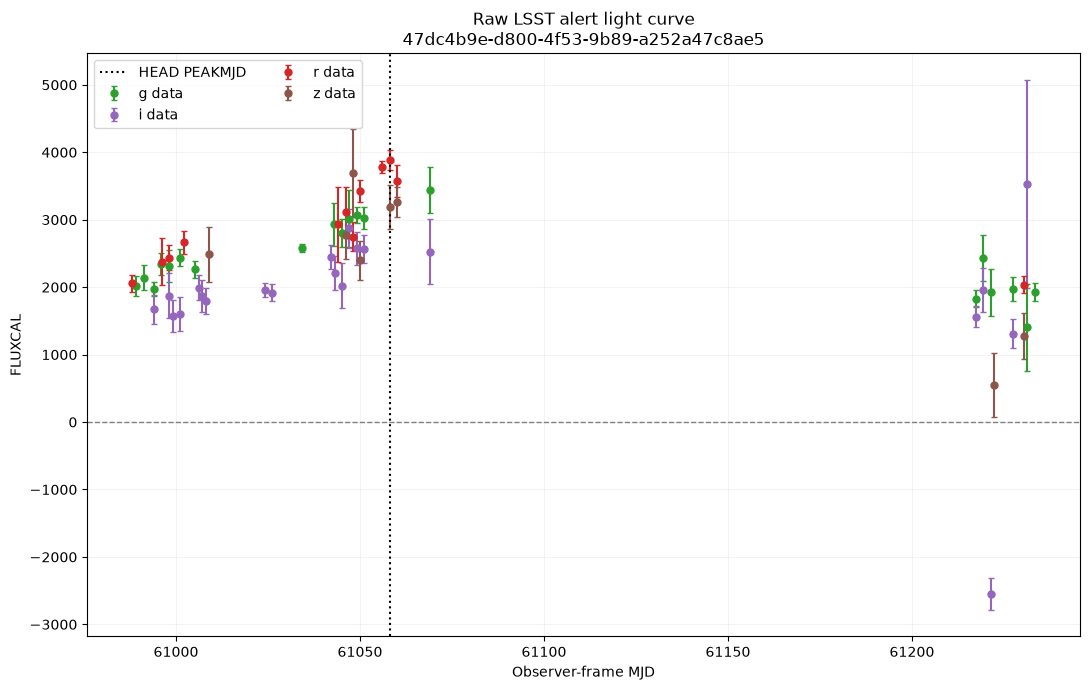

In [181]:
band_colours = {
    "u": "#7B2CBF",
    "g": "#2CA02C",
    "r": "#D62728",
    "i": "#9467BD",
    "z": "#8C564B",
    "y": "#BCBD22",
}

fig, ax = plt.subplots(figsize=(11, 7))

for band in sorted(lsst_lc["BAND"].unique()):
    band_data = lsst_lc[
        lsst_lc["BAND"] == band
    ]

    ax.errorbar(
        band_data["MJD"],
        band_data["FLUXCAL"],
        yerr=band_data["FLUXCALERR"],
        fmt="o",
        ms=5,
        capsize=2,
        color=band_colours.get(band, "black"),
        label=f"{band} data",
    )

ax.axhline(
    0,
    color="0.5",
    linestyle="--",
    linewidth=1,
)

ax.axvline(
    float(head_row["PEAKMJD"]),
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="HEAD PEAKMJD",
)

ax.set_xlabel("Observer-frame MJD")
ax.set_ylabel("FLUXCAL")
ax.set_title(
    f"Raw LSST alert light curve\n{target_snid}"
)
ax.legend(ncol=2)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

### Fit Foundation object

In [39]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel
from pathlib import Path
import pandas as pd

from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from bayesn import SEDmodel

In [45]:
project_root = Path.cwd().parent
lsst_zip = project_root / "data" / "Foundation_DR1.zip"

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from pathlib import Path
from bayesn import SEDmodel

snid = "ASASSN-15so"

sn_file = (
    project_root
    / "data"
    / "Foundation_DR1_extracted"
    / "Foundation_DR1"
    / f"Foundation_DR1_{snid}.txt"
)

filt_map = {
    "g": "g_PS1",
    "r": "r_PS1",
    "i": "i_PS1",
    "z": "z_PS1",
}

z_quantiles = jnp.linspace(0.001, 0.30, 101)

model = SEDmodel(load_model="T21_model")

samples, sn_props = model.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    photoz=True,
    z_quantiles=z_quantiles,
    chain_method="parallel",
)


Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/jax/_src/api_util.py:691: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.12      0.05      0.12      0.03      0.20    312.85      1.01
          Ds[0]     32.81      0.05     32.81     32.73     32.89    342.44      1.01
 eps_tform[0,0]      0.63      0.57      0.65     -0.30      1.61    670.75      1.01
 eps_tform[0,1]      1.05      0.49      1.06      0.27      1.81    722.90      1.00
 eps_tform[0,2]      1.34      0.50      1.33      0.56      2.27    862.89      1.00
 eps_tform[0,3]     -0.02      0.64     -0.02     -1.06      1.05    772.42      1.00
 eps_tform[0,4]     -1.37      0.61     -1.37     -2.31     -0.39    483.38      1.00
 eps_tform[0,5]     -0.28      0.53     -0.27     -1.14      0.58    750.38      1.00
 eps_tform[0,6]      0.14      0.59      0.13     -0.74      1.21    436.46      1.00
 eps_tform[0,7]     -0.19      0.42     -0.20     -0.97      0.40    380.95      1.01
 eps_tform[0,8]      0.67      0.50      0.69     -0.

In [47]:
# Get flux from chains

meta, tables = sncosmo.read_snana_ascii(
    str(sn_file),
    default_tablename="OBS",
)

lc = tables["OBS"].to_pandas().sort_values("MJD")

plot_samples = dict(samples)
plot_samples.setdefault("mu", plot_samples["Ds"])
plot_samples.setdefault(
    "delM",
    np.zeros_like(plot_samples["Ds"]),
)

model.peak_mjds = np.array([float(meta["SEARCH_PEAKMJD"])])
model.ebv = np.array([float(meta["MWEBV"])])

bands = [["g_PS1", "r_PS1", "i_PS1", "z_PS1"]]

model_mjd, model_flux, model_std = (
    model.get_flux_from_chains_photoz(
        chains=plot_samples,
        bands=bands,
        num_sne=1,
        n_grid=200,
        num_samples=200,
    )
)

Getting photo-z posterior-predictive light curves from chains...






  0%|                                                                                                                      | 0/1 [00:00<?, ?it/s]



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:15<00:00, 15.73s/it]


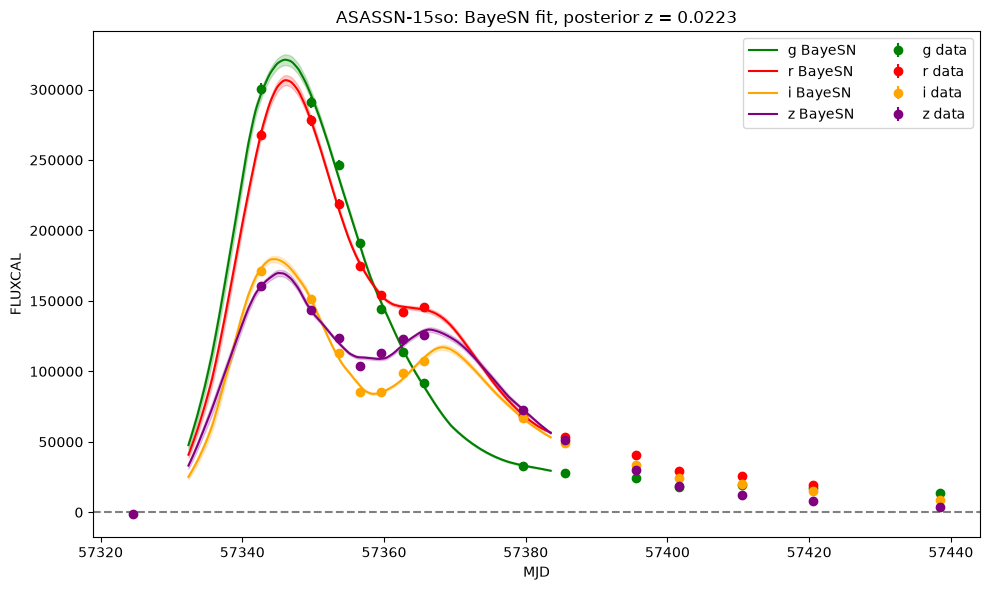

In [48]:
colours = {
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
}

fig, ax = plt.subplots(figsize=(10, 6))

for i, band in enumerate(["g", "r", "i", "z"]):
    observed = lc[lc["FLT"].astype(str).str.strip() == band]

    ax.errorbar(
        observed["MJD"],
        observed["FLUXCAL"],
        yerr=observed["FLUXCALERR"],
        fmt="o",
        color=colours[band],
        label=f"{band} data",
    )

    ax.plot(
        model_mjd[0],
        model_flux[0, i],
        color=colours[band],
        label=f"{band} BayeSN",
    )

    ax.fill_between(
        model_mjd[0],
        model_flux[0, i] - model_std[0, i],
        model_flux[0, i] + model_std[0, i],
        color=colours[band],
        alpha=0.2,
    )

z = np.asarray(samples["z"]).reshape(-1)

ax.axhline(0, color="grey", linestyle="--")
ax.set(
    xlabel="MJD",
    ylabel="FLUXCAL",
    title=f"{snid}: BayeSN fit, posterior z = {np.median(z):.4f}",
)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

### LSST data

In [193]:
target_snid = "19898c3a-46fb-4f17-8d03-ae5b208bd820"
head_row = head_data[
    np.char.strip(head_data["SNID"].astype(str)) == target_snid
][0]

def get_lightcurve(head_row, phot_table):
    start = int(head_row["PTROBS_MIN"]) - 1
    stop = int(head_row["PTROBS_MAX"])

    lc = pd.DataFrame(
        phot_table[start:stop]
    )

    # Convert byte strings such as b"g" into normal strings
    lc["BAND"] = (
        lc["BAND"]
        .str.decode("utf-8")
        .str.strip()
        if lc["BAND"].dtype == object
        else lc["BAND"].astype(str).str.strip()
    )

    return lc
    
target_lc = get_lightcurve(head_row, phot_data)

In [183]:
target_snid = "47dc4b9e-d800-4f53-9b89-a252a47c8ae5"

snids = np.char.strip(
    head_data["SNID"].astype(str)
)

head_row = head_data[snids == target_snid][0]

target_lc = get_lightcurve(
    head_row,
    phot_data,
)

print("Extracted observations:", len(target_lc))
display(
    target_lc[
        ["MJD", "BAND", "FLUXCAL", "FLUXCALERR"]
    ].head()
)

Extracted observations: 61


,MJD,BAND,FLUXCAL,FLUXCALERR
0,60988.1233,r,2054.600098,121.489998
1,60989.2050,g,2012.300049,150.699997
2,60991.2372,g,2142.100098,189.130005
3,60994.0838,g,1973.199951,110.610001
4,60994.1448,i,1670.400024,214.039993


In [184]:
# Keep valid measurements
target_lc = target_lc[
    np.isfinite(target_lc["MJD"])
    & np.isfinite(target_lc["FLUXCAL"])
    & np.isfinite(target_lc["FLUXCALERR"])
    & (target_lc["FLUXCALERR"] > 0)
].copy()

# Remove possible "LSST_" prefix
target_lc["BAND"] = (
    target_lc["BAND"]
    .astype(str)
    .str.strip()
    .str.replace("LSST_", "", regex=False)
)

print(target_lc["BAND"].value_counts())

BAND
i    21
g    20
r    12
z     8
Name: count, dtype: int64


In [185]:
import jax.numpy as jnp
from bayesn import SEDmodel

# Use the highest-SNR observation as an approximate peak
snr = target_lc["FLUXCAL"] / target_lc["FLUXCALERR"]
peak_mjd = float(target_lc.loc[snr.idxmax(), "MJD"])

import numpy as np
import jax.numpy as jnp
from bayesn import SEDmodel

t = np.asarray(target_lc["MJD"], dtype=float)
flux = np.asarray(target_lc["FLUXCAL"], dtype=float)
flux_err = np.asarray(target_lc["FLUXCALERR"], dtype=float)
filters = np.asarray(target_lc["BAND"]).astype(str)

LSST_FILT_MAP = {
    "u": "u_LSST",
    "g": "g_LSST",
    "r": "r_LSST",
    "i": "i_LSST",
    "z": "z_LSST",
    "y": "y_LSST",
}

# Broad uniform redshift prior
zq_broad = jnp.linspace(0.001, 1.0, 101)

model = SEDmodel(load_model="T21_model")

samples, props = model.fit(
    t,
    flux,
    np.clip(flux_err, flux/10, np.inf),
    #flux_err,
    filters,
    ebv_mw=float(head_row["MWEBV"]),
    peak_mjd=float(head_row["PEAKMJD"]),
    filt_map=LSST_FILT_MAP,
    photoz=True,
    z_quantiles=zq_broad,
    chain_method="parallel",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/jax/_src/api_util.py:691: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
z_samples = np.asarray(samples["z"]).reshape(-1)

print("Posterior median z:", np.median(z_samples))
print("68% interval:", np.percentile(z_samples, [16, 84]))


In [ ]:
plot_samples = dict(samples)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(plot_samples["Ds"])

# Tell the model about this object's metadata
model.peak_mjds = np.array(
    [float(head_row["PEAKMJD"])]
)

model.ebv = np.array(
    [float(head_row["MWEBV"])]
)

observed_bands = [
    band for band in ["u", "g", "r", "i", "z", "y"]
    if band in np.unique(filters)
]

fit_bands = [[
    LSST_FILT_MAP[band]
    for band in observed_bands
]]

model_mjd, model_mean, model_std = (
    model.get_flux_from_chains_photoz(
        chains=plot_samples,
        bands=fit_bands,
        num_sne=1,
        n_grid=200,
        num_samples=200,
    )
)

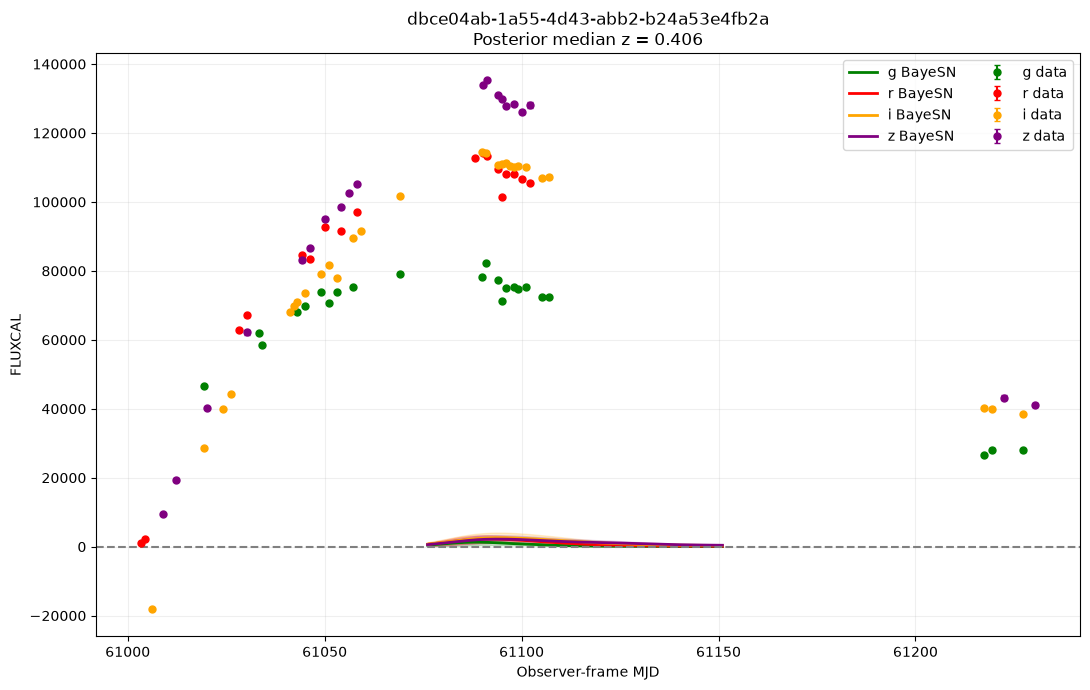

In [58]:
colours = {
    "u": "blue",
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
    "y": "brown",
}

fig, ax = plt.subplots(figsize=(11, 7))

for band_index, band in enumerate(observed_bands):
    use = filters == band
    colour = colours[band]

    ax.errorbar(
        t[use],
        flux[use],
        yerr=flux_err[use],
        fmt="o",
        ms=5,
        capsize=2,
        color=colour,
        label=f"{band} data",
        zorder=3,
    )

    fitted_flux = model_mean[0, band_index]
    fitted_std = model_std[0, band_index]

    ax.plot(
        model_mjd[0],
        fitted_flux,
        color=colour,
        linewidth=2,
        label=f"{band} BayeSN",
    )

    ax.fill_between(
        model_mjd[0],
        fitted_flux - fitted_std,
        fitted_flux + fitted_std,
        color=colour,
        alpha=0.18,
    )

z_median = np.median(
    np.asarray(samples["z"]).reshape(-1)
)

ax.axhline(0, color="grey", linestyle="--")
ax.set(
    xlabel="Observer-frame MJD",
    ylabel="FLUXCAL",
    title=f"{target_snid}\nPosterior median z = {z_median:.3f}",
)
ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [59]:
print("Observed MJD range:", t.min(), "to", t.max())
print("Model MJD range:", model_mjd[0].min(), "to", model_mjd[0].max())

print("Observed flux range:", flux.min(), "to", flux.max())
print("Model flux range:", model_mean.min(), "to", model_mean.max())

Observed MJD range: 61003.3367 to 61230.4212
Model MJD range: 61076.12022382599 to 61150.987854696046
Observed flux range: -18166.0 to 135290.0
Model flux range: 37.01107388225982 to 2585.8293410218153


In [60]:
for band in observed_bands:
    use = filters == band

    print(f"\n{band}")
    print("N points:", use.sum())
    print("Flux range:", flux[use].min(), flux[use].max())
    print("Median flux:", np.median(flux[use]))
    print("Positive fraction:", np.mean(flux[use] > 0))
    print("SNR > 3:", np.sum(flux[use] / flux_err[use] > 3))


g
N points: 23
Flux range: 26589.0 82421.0
Median flux: 72475.0
Positive fraction: 1.0
SNR > 3: 23

r
N points: 18
Flux range: 1007.5999755859375 114060.0
Median flux: 99146.5
Positive fraction: 1.0
SNR > 3: 18

i
N points: 28
Flux range: -18166.0 114580.0
Median flux: 85579.0
Positive fraction: 0.9642857142857143
SNR > 3: 27

z
N points: 20
Flux range: 9390.7001953125 135290.0
Median flux: 100529.0
Positive fraction: 1.0
SNR > 3: 20


### Debug to work 

In [61]:
LSST_ZP = 31.4
FLUXCAL_ZP = 27.5

conversion = 10 ** (0.4 * (FLUXCAL_ZP - LSST_ZP))

flux_fluxcal = flux * conversion
flux_err_fluxcal = flux_err * conversion

print("Conversion factor:", conversion)
print("Original flux range:", flux.min(), flux.max())
print("FLUXCAL range:", flux_fluxcal.min(), flux_fluxcal.max())

Conversion factor: 0.02754228703338169
Original flux range: -18166.0 135290.0
FLUXCAL range: -500.3331862484118 3726.1960127462085


In [63]:
filters_plot = np.asarray(filters).astype("U").reshape(-1)
plot_bands = [str(b).strip() for b in fit_bands]

print("Filter values:", np.unique(filters_plot))
print("Model band order:", plot_bands)
print("Shapes:", filters_plot.shape, np.asarray(t).shape)

Filter values: ['g' 'i' 'r' 'z']
Model band order: ["['g_LSST', 'r_LSST', 'i_LSST', 'z_LSST']"]
Shapes: (89,) (89,)


In [91]:
target_snid = "8f156832-1cb6-49e8-a3d4-b5bf27fc0ba1" 

snids = np.char.strip(
    head_data["SNID"].astype(str)
)

head_row = head_data[snids == target_snid][0]

target_lc = get_lightcurve(
    head_row,
    phot_data,
)

print("Extracted observations:", len(target_lc))
display(
    target_lc[
        ["MJD", "BAND", "FLUXCAL", "FLUXCALERR"]
    ].head()
)

Extracted observations: 37


,MJD,BAND,FLUXCAL,FLUXCALERR
0,61024.1376,i,68965.0,193.029999
1,61026.1990,i,94453.0,256.950012
2,61034.1530,g,174170.0,218.289993
3,61042.1004,i,103280.0,459.000000
4,61043.0626,g,114860.0,550.849976


In [97]:
print(target_lc.dtypes)

MJD             >f8
BAND            str
DETNUM          >i2
IMGNUM        int32
FIELD           str
PHOTFLAG      int32
PHOTPROB        >f4
FLUXCAL         >f4
FLUXCALERR      >f4
PSF_SIG1        >f4
PSF_SIG2        >f4
PSF_RATIO       >f4
SKY_SIG         >f4
SKY_SIG_T       >f4
RDNOISE         >f4
ZEROPT          >f4
ZEROPT_ERR      >f4
TEXPOSE         >f4
GAIN            >f4
XPIX            >f4
YPIX            >f4
dtype: object


In [117]:

#target_lc = target_lc.astype({"MJD": ">f4"})
float_cols = target_lc.select_dtypes(include="float").columns
target_lc[float_cols] = target_lc[float_cols].astype("float32")
print(target_lc.dtypes)


MJD           float32
BAND              str
DETNUM            >i2
IMGNUM          int32
FIELD             str
PHOTFLAG        int32
PHOTPROB      float32
FLUXCAL       float32
FLUXCALERR    float32
PSF_SIG1      float32
PSF_SIG2      float32
PSF_RATIO     float32
SKY_SIG       float32
SKY_SIG_T     float32
RDNOISE       float32
ZEROPT        float32
ZEROPT_ERR    float32
TEXPOSE       float32
GAIN          float32
XPIX          float32
YPIX          float32
dtype: object


In [121]:
mjd_mask = target_lc["MJD"] < 61100
print(mjd_mask.value_counts())


MJD
True     23
False    14
Name: count, dtype: int64


In [122]:
target_lc["DETNUM"] = target_lc["DETNUM"].astype("int16")

In [123]:
# Keep valid measurements
target_lc = target_lc[
    np.isfinite(target_lc["MJD"])
    & np.isfinite(target_lc["FLUXCAL"])
    & np.isfinite(target_lc["FLUXCALERR"])
    & (target_lc["FLUXCALERR"] > 0)
    & (target_lc["MJD"] < 61100)
].copy()

# Remove possible "LSST_" prefix
target_lc["BAND"] = (
    target_lc["BAND"]
    .astype(str)
    .str.strip()
    .str.replace("LSST_", "", regex=False)
)

print(target_lc["BAND"].value_counts())

BAND
i    6
r    6
z    6
g    5
Name: count, dtype: int64


In [124]:
snr = target_lc["FLUXCAL"] / target_lc["FLUXCALERR"]
peak_mjd = float(target_lc.loc[snr.idxmax(), "MJD"])

import numpy as np
import jax.numpy as jnp
from bayesn import SEDmodel

t = np.asarray(target_lc["MJD"], dtype=float)
flux = np.asarray(target_lc["FLUXCAL"], dtype=float)
flux_err = np.asarray(target_lc["FLUXCALERR"], dtype=float)
filters = np.asarray(target_lc["BAND"]).astype(str)

LSST_FILT_MAP = {
    "u": "u_LSST",
    "g": "g_LSST",
    "r": "r_LSST",
    "i": "i_LSST",
    "z": "z_LSST",
    "y": "y_LSST",
}

# Broad uniform redshift prior
zq_broad = jnp.linspace(0, 1, 101)

model = SEDmodel(load_model="T21_model")

samples, props = model.fit(
    t,
    flux,
    np.clip(flux_err, flux/10, np.inf),
    filters,
    ebv_mw=float(head_row["MWEBV"]),
    peak_mjd=float(head_row["PEAKMJD"]),
    filt_map=LSST_FILT_MAP,
    photoz=True,
    z_quantiles=zq_broad,
    chain_method="parallel",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/jax/_src/api_util.py:691: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.46      0.15      0.46      0.21      0.70    539.13      1.01
          Ds[0]     33.02      0.13     33.01     32.80     33.21    411.40      1.01
 eps_tform[0,0]      0.32      0.96      0.34     -1.24      1.86   1020.91      1.00
 eps_tform[0,1]      0.26      0.93      0.24     -1.13      1.87   1262.78      1.00
 eps_tform[0,2]      0.24      0.96      0.24     -1.32      1.75   1046.34      1.00
 eps_tform[0,3]      0.19      1.00      0.17     -1.33      1.87   1567.67      1.00
 eps_tform[0,4]      0.40      0.96      0.39     -1.09      1.98    886.56      1.00
 eps_tform[0,5]      0.02      1.03     -0.01     -1.61      1.72   1435.81      1.00
 eps_tform[0,6]     -0.06      0.95     -0.08     -1.63      1.40   1023.73      1.00
 eps_tform[0,7]      0.17      0.97      0.17     -1.49      1.74   1384.05      1.00
 eps_tform[0,8]      0.39      0.89      0.42     -1.

In [125]:
z_samples = np.asarray(samples["z"]).reshape(-1)

print("Posterior median z:", np.median(z_samples))
print("68% interval:", np.percentile(z_samples, [16, 84]))


Posterior median z: 0.06013942293430567
68% interval: [0.05260565 0.06697343]


In [126]:
plot_samples = dict(samples)
z_samples = np.asarray(samples["z"]).reshape(-1)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(plot_samples["Ds"])

# Tell the model about this object's metadata
model.peak_mjds = np.array(
    [float(head_row["PEAKMJD"])]
)

model.ebv = np.array(
    [float(head_row["MWEBV"])]
)

observed_bands = [
    band for band in ["u", "g", "r", "i", "z", "y"]
    if band in np.unique(filters)
]

fit_bands = [[
    LSST_FILT_MAP[band]
    for band in observed_bands
]]

model_mjd, model_mean, model_std = (
    model.get_flux_from_chains_photoz(
        chains=plot_samples,
        bands=fit_bands,
        num_sne=1,
        n_grid=200,
        num_samples=200,
    )
)

Getting photo-z posterior-predictive light curves from chains...






  0%|                                                                                                                      | 0/1 [00:00<?, ?it/s]



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.60s/it]


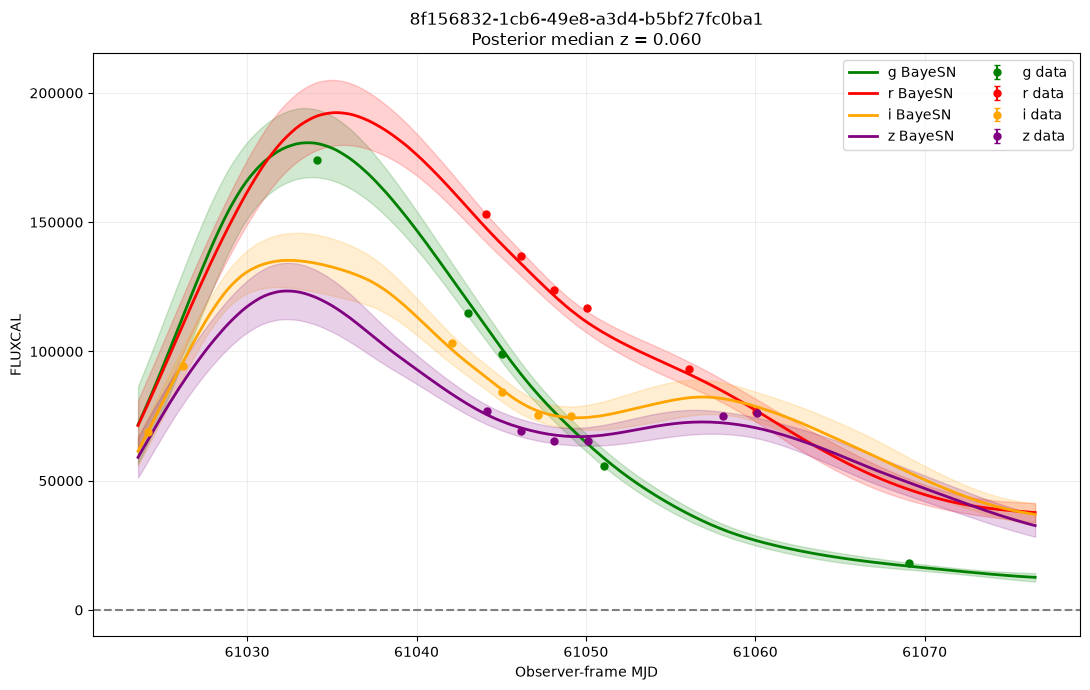


g
N points: 10
Flux range: 1218.199951171875 174170.0
Median flux: 10329.849975585938
Positive fraction: 1.0
SNR > 1000: 0

r
N points: 8
Flux range: 1422.5 153170.0
Median flux: 105028.5
Positive fraction: 1.0
SNR > 1000: 0

i
N points: 11
Flux range: -4350.60009765625 103280.0
Median flux: 68965.0
Positive fraction: 0.5454545454545454
SNR > 1000: 0

z
N points: 8
Flux range: 401.3599853515625 76929.0
Median flux: 67410.5
Positive fraction: 1.0
SNR > 1000: 0


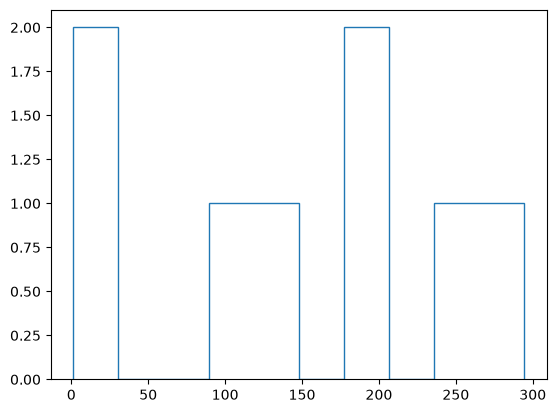

In [77]:
for band in observed_bands:
    use = filters == band

    print(f"\n{band}")
    print("N points:", use.sum())
    print("Flux range:", flux[use].min(), flux[use].max())
    print("Median flux:", np.median(flux[use]))
    print("Positive fraction:", np.mean(flux[use] > 0))
    print("SNR > 1000:", np.sum(flux[use] / flux_err[use] > 1000))


counts, bins = np.histogram(flux[use]/flux_err[use])
plt.stairs(counts, bins)

In [215]:
target_snid = "dbf14a27-ed8f-43d2-9263-de157d67b408"

snids = np.char.strip(
    head_data["SNID"].astype(str)
)

head_row = head_data[snids == target_snid][0]

target_lc = get_lightcurve(
    head_row,
    phot_data,
)

print("Extracted observations:", len(target_lc))
display(
    target_lc[
        ["MJD", "BAND", "FLUXCAL", "FLUXCALERR"]
    ].head()
)

Extracted observations: 22


,MJD,BAND,FLUXCAL,FLUXCALERR
0,61003.3244,g,1503.500000,165.990005
1,61019.2897,g,2637.899902,301.250000
2,61028.3221,r,3503.600098,154.929993
3,61033.2850,g,2463.100098,133.509995
4,61049.1175,g,2674.100098,207.309998


In [216]:
target_snid = "dbf14a27-ed8f-43d2-9263-de157d67b408"
head_row = head_data[
    np.char.strip(head_data["SNID"].astype(str)) == target_snid
][0]

def get_lightcurve(head_row, phot_table):
    start = int(head_row["PTROBS_MIN"]) - 1
    stop = int(head_row["PTROBS_MAX"])

    lc = pd.DataFrame(
        phot_table[start:stop]
    )

    # Convert byte strings such as b"g" into normal strings
    lc["BAND"] = (
        lc["BAND"]
        .str.decode("utf-8")
        .str.strip()
        if lc["BAND"].dtype == object
        else lc["BAND"].astype(str).str.strip()
    )

    return lc
    
target_lc = get_lightcurve(head_row, phot_data)

In [217]:
idx = matches[0]

# All object-level information
head_row = head_data[idx]

# Locate this object's observations in the PHOT table
start = int(head_row["PTROBS_MIN"]) - 1
stop = int(head_row["PTROBS_MAX"])

# Extract all photometric observations for this object
lightcurve = phot_data[start:stop].copy()

print("HEAD row index:", idx)
print("PHOT rows:", start, "to", stop - 1)
print("Number of observations:", len(lightcurve))

HEAD row index: 14921
PHOT rows: 79561 to 79621
Number of observations: 61


In [211]:
valid = (
    np.isfinite(lightcurve_df["MJD"])
    & np.isfinite(lightcurve_df["FLUXCAL"])
    & np.isfinite(lightcurve_df["FLUXCALERR"])
    & (lightcurve_df["FLUXCALERR"] > 0)
)

lsst_lc = (
    lightcurve_df.loc[valid]
    .sort_values("MJD")
    .reset_index(drop=True)
)

print(
    f"Retained {len(lsst_lc)} of "
    f"{len(lightcurve_df)} observations"
)

Retained 61 of 61 observations


In [207]:
float_cols = target_lc.select_dtypes(include="float").columns
target_lc[float_cols] = target_lc[float_cols].astype("float32")
print(target_lc.dtypes)

MJD           float32
BAND              str
DETNUM            >i2
IMGNUM          int32
FIELD             str
PHOTFLAG        int32
PHOTPROB      float32
FLUXCAL       float32
FLUXCALERR    float32
PSF_SIG1      float32
PSF_SIG2      float32
PSF_RATIO     float32
SKY_SIG       float32
SKY_SIG_T     float32
RDNOISE       float32
ZEROPT        float32
ZEROPT_ERR    float32
TEXPOSE       float32
GAIN          float32
XPIX          float32
YPIX          float32
dtype: object


In [208]:
mjd_mask = target_lc["MJD"] < 61100
print(mjd_mask.value_counts())
target_lc["DETNUM"] = target_lc["DETNUM"].astype("int16")
# Keep valid measurements
target_lc = target_lc[
    np.isfinite(target_lc["MJD"])
    & np.isfinite(target_lc["FLUXCAL"])
    & np.isfinite(target_lc["FLUXCALERR"])
    & (target_lc["FLUXCALERR"] > 0)
    & (target_lc["MJD"] < 61100)
].copy()

# Remove possible "LSST_" prefix
target_lc["BAND"] = (
    target_lc["BAND"]
    .astype(str)
    .str.strip()
    .str.replace("LSST_", "", regex=False)
)

print(target_lc["BAND"].value_counts())

MJD
True    22
Name: count, dtype: int64
BAND
g    11
r     6
z     3
i     2
Name: count, dtype: int64


In [209]:
snr = target_lc["FLUXCAL"] / target_lc["FLUXCALERR"]
peak_mjd = float(target_lc.loc[snr.idxmax(), "MJD"])

import numpy as np
import jax.numpy as jnp
from bayesn import SEDmodel

t = np.asarray(target_lc["MJD"], dtype=float)
flux = np.asarray(target_lc["FLUXCAL"], dtype=float)
flux_err = np.asarray(target_lc["FLUXCALERR"], dtype=float)
filters = np.asarray(target_lc["BAND"]).astype(str)

LSST_FILT_MAP = {
    "u": "u_LSST",
    "g": "g_LSST",
    "r": "r_LSST",
    "i": "i_LSST",
    "z": "z_LSST",
    "y": "y_LSST",
}

# Broad uniform redshift prior
zq_broad = jnp.linspace(0, 1, 101)

model = SEDmodel(load_model="T21_model")

samples, props = model.fit(
    t,
    flux,
    np.clip(flux_err, flux/10, np.inf),
    filters,
    ebv_mw=float(head_row["MWEBV"]),
    peak_mjd=float(head_row["PEAKMJD"]),
    filt_map=LSST_FILT_MAP,
    photoz=True,
    z_quantiles=zq_broad,
    chain_method="parallel",
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/jax/_src/api_util.py:691: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.05      0.05      0.03      0.00      0.11    541.70      1.00
          Ds[0]     37.96      0.11     37.96     37.77     38.14    728.73      1.00
 eps_tform[0,0]      0.78      0.84      0.74     -0.58      2.16   1264.45      1.00
 eps_tform[0,1]     -0.33      0.96     -0.35     -2.08      1.17   1357.81      1.00
 eps_tform[0,2]      0.08      1.00      0.09     -1.31      1.91   1384.46      1.00
 eps_tform[0,3]     -0.11      1.03     -0.16     -1.68      1.71   2513.44      1.00
 eps_tform[0,4]     -0.31      0.95     -0.33     -1.78      1.37   1654.55      1.00
 eps_tform[0,5]      0.10      1.03      0.10     -1.65      1.65   1847.38      1.00
 eps_tform[0,6]     -0.23      1.00     -0.27     -1.74      1.41   1708.77      1.00
 eps_tform[0,7]     -0.05      0.99     -0.06     -1.62      1.58   1446.51      1.00
 eps_tform[0,8]      0.49      1.04      0.49     -1.

In [212]:
z_samples = np.asarray(samples["z"]).reshape(-1)

plot_samples = dict(samples)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(plot_samples["Ds"])

# Tell the model about this object's metadata
model.peak_mjds = np.array(
    [float(head_row["PEAKMJD"])]
)

model.ebv = np.array(
    [float(head_row["MWEBV"])]
)

observed_bands = [
    band for band in ["u", "g", "r", "i", "z", "y"]
    if band in np.unique(filters)
]

fit_bands = [[
    LSST_FILT_MAP[band]
    for band in observed_bands
]]

model_mjd, model_mean, model_std = (
    model.get_flux_from_chains_photoz(
        chains=plot_samples,
        bands=fit_bands,
        num_sne=1,
        n_grid=200,
        num_samples=200,
    )
)

Getting photo-z posterior-predictive light curves from chains...






  0%|                                                                                                                    | 0/1 [00:00<?, ?it/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.78s/it]


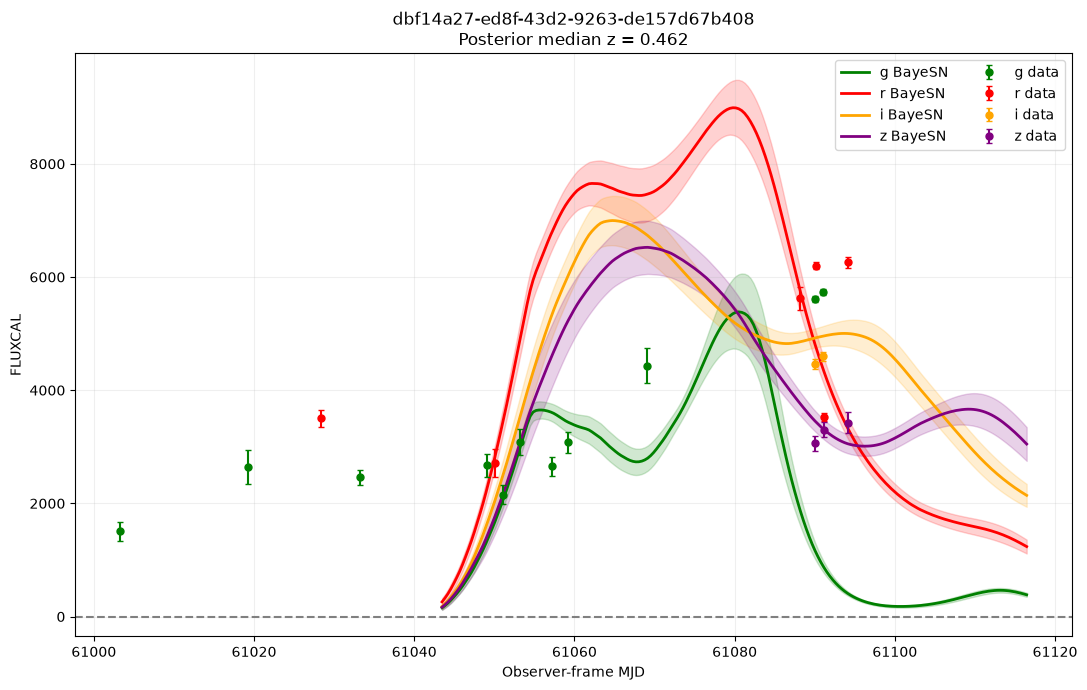

In [213]:
colours = {
    "u": "blue",
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
    "y": "brown",
}

fig, ax = plt.subplots(figsize=(11, 7))

for band_index, band in enumerate(observed_bands):
    use = filters == band
    colour = colours[band]

    ax.errorbar(
        t[use],
        flux[use],
        yerr=flux_err[use],
        fmt="o",
        ms=5,
        capsize=2,
        color=colour,
        label=f"{band} data",
        zorder=3,
    )

    fitted_flux = model_mean[0, band_index]
    fitted_std = model_std[0, band_index]

    ax.plot(
        model_mjd[0],
        fitted_flux,
        color=colour,
        linewidth=2,
        label=f"{band} BayeSN",
    )

    ax.fill_between(
        model_mjd[0],
        fitted_flux - fitted_std,
        fitted_flux + fitted_std,
        color=colour,
        alpha=0.18,
    )

z_median = np.median(
    np.asarray(samples["z"]).reshape(-1)
)

ax.axhline(0, color="grey", linestyle="--")
ax.set(
    xlabel="Observer-frame MJD",
    ylabel="FLUXCAL",
    title=f"{target_snid}\nPosterior median z = {z_median:.3f}",
)
ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Full cleaned workflow for one object 

In [337]:
# Select SNID

target_snid = "a3f7ac57-349f-44a8-bc11-dd101444ace1"
#"dbf14a27-ed8f-43d2-9263-de157d67b408"

# Find object in HEAD table
snids = np.char.strip(
    head_data["SNID"].astype(str)
)

matches = np.flatnonzero(snids == target_snid)

if len(matches) == 0:
    raise ValueError(f"SNID {target_snid} not found")

head_row = head_data[matches[0]]

# Extract light curve
target_lc = get_lightcurve(
    head_row,
    phot_data,
)

print("Extracted observations:", len(target_lc))

# Convert FITS numerical columns to values
float_cols = target_lc.select_dtypes(
    include="float"
).columns

target_lc[float_cols] = target_lc[
    float_cols
].astype("float32")
target_lc["DETNUM"] = target_lc["DETNUM"].astype("int16")

# Keep valid measurements (apply cut at MJD days here)
target_lc = target_lc[
    np.isfinite(target_lc["MJD"])
    & np.isfinite(target_lc["FLUXCAL"])
    & np.isfinite(target_lc["FLUXCALERR"])
    & (target_lc["FLUXCALERR"] > 0)
    #& (target_lc["MJD"] < 61100)
].copy()

# Remove LSST_ prefix from the bands
target_lc["BAND"] = (
    target_lc["BAND"]
    .astype(str)
    .str.strip()
    .str.replace("LSST_", "", regex=False)
)

target_lc = (
    target_lc
    .sort_values("MJD")
    .reset_index(drop=True)
)

print("Retained observations:", len(target_lc))
print(target_lc["BAND"].value_counts().sort_index())

display(
    target_lc[
        ["MJD", "BAND", "FLUXCAL", "FLUXCALERR"]
    ].head()
)

Extracted observations: 149
Retained observations: 149
BAND
g    31
i    34
r    31
u    17
y     7
z    29
Name: count, dtype: int64


,MJD,BAND,FLUXCAL,FLUXCALERR
0,61024.292969,i,3800.199951,98.334999
1,61026.214844,i,3795.199951,317.170013
2,61028.328125,r,3106.199951,57.818001
3,61029.324219,u,2729.500000,125.769997
4,61029.332031,g,2677.300049,154.949997


In [338]:
t = np.asarray(
    target_lc["MJD"],
    dtype=float,
)

flux = np.asarray(
    target_lc["FLUXCAL"],
    dtype=float,
)

flux_err = np.asarray(
    target_lc["FLUXCALERR"],
    dtype=float,
)

filters = np.asarray(
    target_lc["BAND"],
    dtype=str,
)

# Estimate peak MJD from the highest-SNR observation
snr = flux / flux_err
#peak_mjd = float(t[np.argmax(snr)])

print("MJD range:", t.min(), "to", t.max())
#print("Estimated peak MJD:", peak_mjd)
print("Observed bands:", np.unique(filters))

MJD range: 61024.29296875 to 61204.97265625
Observed bands: ['g' 'i' 'r' 'u' 'y' 'z']


In [341]:
snr = target_lc["FLUXCAL"] / target_lc["FLUXCALERR"]
#peak_mjd = float(target_lc.loc[snr.idxmax(), "MJD"])
peak_mjd = float(head_row["PEAKMJD"])

target_lc = target_lc[
    target_lc["MJD"].between(
        peak_mjd - 20,
        peak_mjd + 200,
    )
].copy()

t = np.asarray(target_lc["MJD"], dtype=float)
flux = np.asarray(target_lc["FLUXCAL"], dtype=float)
flux_err = np.asarray(target_lc["FLUXCALERR"], dtype=float)
filters = np.asarray(target_lc["BAND"], dtype=str)

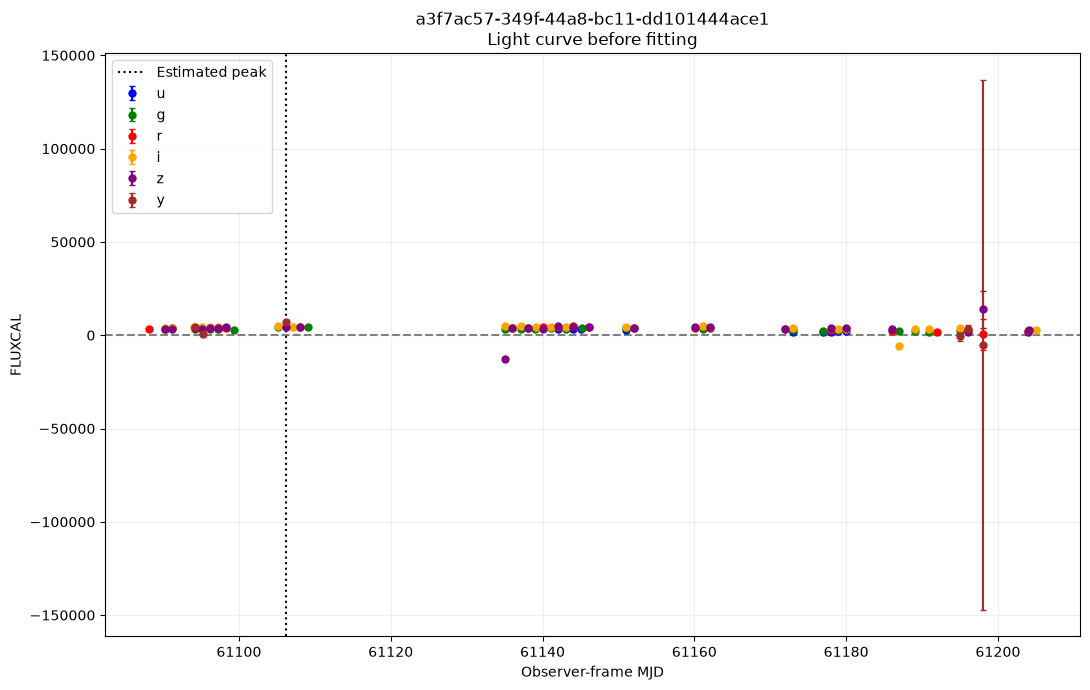

In [342]:
import matplotlib.pyplot as plt
#plot

colours = {
    "u": "blue",
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
    "y": "brown",
}

observed_bands = [
    band
    for band in ["u", "g", "r", "i", "z", "y"]
    if band in np.unique(filters)
]

fig, ax = plt.subplots(figsize=(11, 7))

for band in observed_bands:
    use = filters == band

    ax.errorbar(
        t[use],
        flux[use],
        yerr=flux_err[use],
        fmt="o",
        ms=5,
        capsize=2,
        color=colours[band],
        label=band,
    )

ax.axhline(
    0,
    color="grey",
    linestyle="--",
)

ax.axvline(
    peak_mjd,
    color="black",
    linestyle=":",
    label="Estimated peak",
)

ax.set(
    xlabel="Observer-frame MJD",
    ylabel="FLUXCAL",
    title=f"{target_snid}\nLight curve before fitting",
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [318]:
import jax.numpy as jnp
from bayesn import SEDmodel

LSST_FILT_MAP = {
    "u": "u_LSST",
    "g": "g_LSST",
    "r": "r_LSST",
    "i": "i_LSST",
    "z": "z_LSST",
    "y": "y_LSST",
}

# Broad uniform redshift prior
zq_broad = jnp.linspace(0, 1, 101)

model = SEDmodel(
    load_model="T21_model"
)

samples, props = model.fit(
    t,
    flux,
    np.clip(
        flux_err,
        flux / 10,
        np.inf,
    ),
    filters,
    ebv_mw=float(head_row["MWEBV"]),
    peak_mjd=peak_mjd,
    filt_map=LSST_FILT_MAP,
    photoz=True,
    z_quantiles=zq_broad,
    chain_method="parallel",
)

z_samples = np.asarray(
    samples["z"]
).reshape(-1)

print(
    "Posterior median z:",
    np.median(z_samples),
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/jax/_src/api_util.py:691: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.16      0.10      0.16      0.00      0.31    446.63      1.00
          Ds[0]     37.86      0.15     37.86     37.62     38.10    449.35      1.00
 eps_tform[0,0]     -0.23      0.95     -0.18     -1.68      1.33    785.03      1.00
 eps_tform[0,1]     -0.51      0.89     -0.48     -2.03      0.85   1229.19      1.00
 eps_tform[0,2]     -0.14      1.00     -0.13     -1.91      1.41   1429.40      1.00
 eps_tform[0,3]     -0.26      1.00     -0.21     -1.76      1.51   1414.92      1.00
 eps_tform[0,4]     -0.94      0.91     -0.93     -2.42      0.67   1109.70      1.00
 eps_tform[0,5]      0.01      0.93      0.01     -1.56      1.49   1751.76      1.00
 eps_tform[0,6]     -0.20      0.93     -0.22     -1.67      1.33   1392.22      1.00
 eps_tform[0,7]     -0.08      0.94     -0.08     -1.69      1.37   1021.03      1.00
 eps_tform[0,8]     -0.24      0.92     -0.21     -1.

In [319]:
plot_samples = dict(samples)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(
        plot_samples["Ds"]
    )

# Give BayeSN object's metadata
model.peak_mjds = np.array([peak_mjd])

model.ebv = np.array([
    float(head_row["MWEBV"])
])

fit_bands = [[
    LSST_FILT_MAP[band]
    for band in observed_bands
]]

model_mjd, model_mean, model_std = (
    model.get_flux_from_chains_photoz(
        chains=plot_samples,
        bands=fit_bands,
        num_sne=1,
        n_grid=200,
        num_samples=200,
    )
)

Getting photo-z posterior-predictive light curves from chains...






  0%|                                                                                                                    | 0/1 [00:00<?, ?it/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:12<00:00, 12.11s/it]


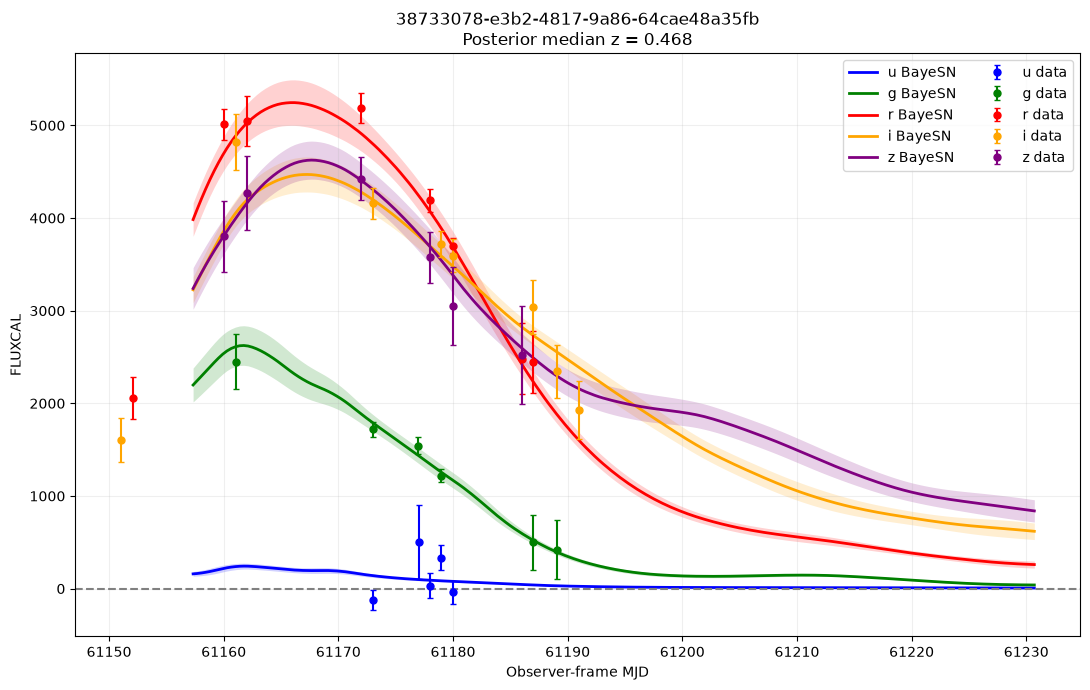

In [320]:
fig, ax = plt.subplots(figsize=(11, 7))

for band_index, band in enumerate(observed_bands):
    use = filters == band
    colour = colours[band]

    # Observed data
    ax.errorbar(
        t[use],
        flux[use],
        yerr=flux_err[use],
        fmt="o",
        ms=5,
        capsize=2,
        color=colour,
        label=f"{band} data",
        zorder=3,
    )

    # BayeSN prediction
    fitted_flux = model_mean[0, band_index]
    fitted_std = model_std[0, band_index]

    ax.plot(
        model_mjd[0],
        fitted_flux,
        color=colour,
        linewidth=2,
        label=f"{band} BayeSN",
        zorder=2,
    )

    ax.fill_between(
        model_mjd[0],
        fitted_flux - fitted_std,
        fitted_flux + fitted_std,
        color=colour,
        alpha=0.18,
        linewidth=0,
        zorder=1,
    )

z_median = np.median(z_samples)

ax.axhline(
    0,
    color="grey",
    linestyle="--",
)

ax.set(
    xlabel="Observer-frame MJD",
    ylabel="FLUXCAL",
    title=(
        f"{target_snid}\n"
        f"Posterior median z = {z_median:.3f}"
    ),
)

ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# small flux cal measurements?????
# real or fake 


In [358]:
target_snid = "666ed310-b587-4689-8873-48cae7cb2673"
#"dbf14a27-ed8f-43d2-9263-de157d67b408"

# Find object in HEAD table
snids = np.char.strip(
    head_data["SNID"].astype(str)
)

matches = np.flatnonzero(snids == target_snid)

if len(matches) == 0:
    raise ValueError(f"SNID {target_snid} not found")

head_row = head_data[matches[0]]

# Extract light curve
target_lc = get_lightcurve(
    head_row,
    phot_data,
)

print("Extracted observations:", len(target_lc))

# Convert FITS numerical columns to values
float_cols = target_lc.select_dtypes(
    include="float"
).columns

target_lc[float_cols] = target_lc[
    float_cols
].astype("float32")
target_lc["DETNUM"] = target_lc["DETNUM"].astype("int16")

# Keep valid measurements (apply cut at MJD days here)
target_lc = target_lc[
    np.isfinite(target_lc["MJD"])
    & np.isfinite(target_lc["FLUXCAL"])
    & np.isfinite(target_lc["FLUXCALERR"])
    & (target_lc["FLUXCALERR"] > 0)
    #& (target_lc["MJD"] < 61100)
].copy()

# Remove LSST_ prefix from the bands
target_lc["BAND"] = (
    target_lc["BAND"]
    .astype(str)
    .str.strip()
    .str.replace("LSST_", "", regex=False)
)

target_lc = (
    target_lc
    .sort_values("MJD")
    .reset_index(drop=True)
)

print("Retained observations:", len(target_lc))
print(target_lc["BAND"].value_counts().sort_index())

display(
    target_lc[
        ["MJD", "BAND", "FLUXCAL", "FLUXCALERR"]
    ].head()
)

Extracted observations: 281
Retained observations: 281
BAND
g    71
i    65
r    68
u     9
y     6
z    62
Name: count, dtype: int64


,MJD,BAND,FLUXCAL,FLUXCALERR
0,61090.179688,i,-8983.700195,1075.099976
1,61090.179688,i,-4489.500000,1080.500000
2,61090.183594,i,-19601.000000,1090.500000
3,61090.183594,i,25.153000,1080.900024
4,61090.183594,i,441.320007,1124.000000


In [359]:
t = np.asarray(
    target_lc["MJD"],
    dtype=float,
)

flux = np.asarray(
    target_lc["FLUXCAL"],
    dtype=float,
)

flux_err = np.asarray(
    target_lc["FLUXCALERR"],
    dtype=float,
)

filters = np.asarray(
    target_lc["BAND"],
    dtype=str,
)

# Estimate peak MJD from the highest-SNR observation
snr = flux / flux_err
#peak_mjd = float(t[np.argmax(snr)])

print("MJD range:", t.min(), "to", t.max())
#print("Estimated peak MJD:", peak_mjd)
print("Observed bands:", np.unique(filters))

MJD range: 61090.1796875 to 61204.0234375
Observed bands: ['g' 'i' 'r' 'u' 'y' 'z']


In [360]:
snr = target_lc["FLUXCAL"] / target_lc["FLUXCALERR"]
#peak_mjd = float(target_lc.loc[snr.idxmax(), "MJD"])
peak_mjd = float(head_row["PEAKMJD"])

target_lc = target_lc[
    target_lc["MJD"].between(
        peak_mjd - 70,
        peak_mjd + 40,
    )
].copy()
peak_mjd = float(head_row["PEAKMJD"])
snr = target_lc["FLUXCAL"] / target_lc["FLUXCALERR"]

target_lc = target_lc[
    target_lc["MJD"].between(peak_mjd - 30, peak_mjd + 50)
    & (snr > -5)
].copy()

t = np.asarray(target_lc["MJD"], dtype=float)
flux = np.asarray(target_lc["FLUXCAL"], dtype=float)
flux_err = np.asarray(target_lc["FLUXCALERR"], dtype=float)
filters = np.asarray(target_lc["BAND"], dtype=str)

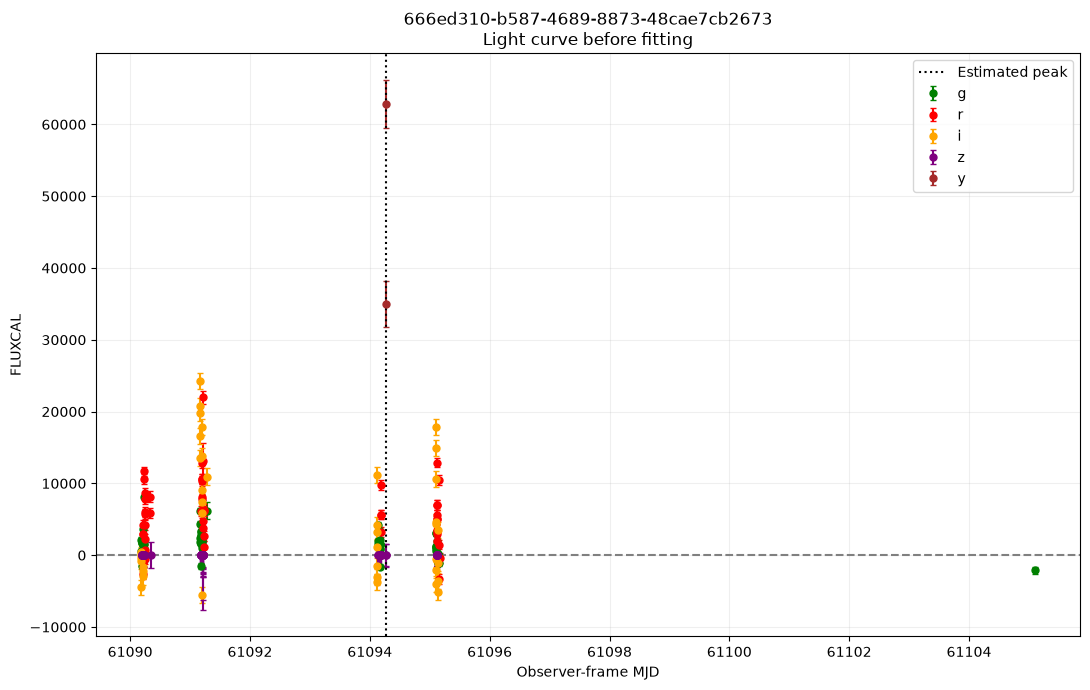

In [361]:
import matplotlib.pyplot as plt
#plot

colours = {
    "u": "blue",
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
    "y": "brown",
}

observed_bands = [
    band
    for band in ["u", "g", "r", "i", "z", "y"]
    if band in np.unique(filters)
]

fig, ax = plt.subplots(figsize=(11, 7))

for band in observed_bands:
    use = filters == band

    ax.errorbar(
        t[use],
        flux[use],
        yerr=flux_err[use],
        fmt="o",
        ms=5,
        capsize=2,
        color=colours[band],
        label=band,
    )

ax.axhline(
    0,
    color="grey",
    linestyle="--",
)

ax.axvline(
    peak_mjd,
    color="black",
    linestyle=":",
    label="Estimated peak",
)

ax.set(
    xlabel="Observer-frame MJD",
    ylabel="FLUXCAL",
    title=f"{target_snid}\nLight curve before fitting",
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [353]:
import jax.numpy as jnp
from bayesn import SEDmodel

LSST_FILT_MAP = {
    "u": "u_LSST",
    "g": "g_LSST",
    "r": "r_LSST",
    "i": "i_LSST",
    "z": "z_LSST",
    "y": "y_LSST",
}

# Broad uniform redshift prior
zq_broad = jnp.linspace(0, 1, 101)

model = SEDmodel(
    load_model="T21_model"
)

samples, props = model.fit(
    t,
    flux,
    np.clip(
        flux_err,
        flux / 10,
        np.inf,
    ),
    filters,
    ebv_mw=float(head_row["MWEBV"]),
    peak_mjd=peak_mjd,
    filt_map=LSST_FILT_MAP,
    photoz=True,
    z_quantiles=zq_broad,
    chain_method="parallel",
)

z_samples = np.asarray(
    samples["z"]
).reshape(-1)

print(
    "Posterior median z:",
    np.median(z_samples),
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/jax/_src/api_util.py:691: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.73      0.35      0.89      0.10      1.06      2.08      5.07
          Ds[0]     36.46      0.27     36.33     36.20     36.96      2.12      4.16
 eps_tform[0,0]     -1.90      1.37     -1.65     -4.30     -0.00      2.88      1.75
 eps_tform[0,1]     -0.48      1.20     -0.59     -2.28      1.55      3.46      1.49
 eps_tform[0,2]     -1.78      1.69     -1.32     -4.90      0.31      2.57      2.04
 eps_tform[0,3]      1.83      1.04      1.78      0.21      3.52     23.29      1.06
 eps_tform[0,4]      2.57      1.94      1.93      0.37      6.24      2.34      2.50
 eps_tform[0,5]      3.52      1.00      3.47      1.84      5.14      6.25      1.20
 eps_tform[0,6]     -0.73      1.19     -0.55     -2.64      1.14      3.42      1.52
 eps_tform[0,7]     -2.39      1.67     -2.82     -4.71      0.52      2.58      2.02
 eps_tform[0,8]      1.00      0.94      0.99     -0.

In [354]:
plot_samples = dict(samples)

if "mu" not in plot_samples:
    plot_samples["mu"] = plot_samples["Ds"]

if "delM" not in plot_samples:
    plot_samples["delM"] = np.zeros_like(
        plot_samples["Ds"]
    )

# Give BayeSN object's metadata
model.peak_mjds = np.array([peak_mjd])

model.ebv = np.array([
    float(head_row["MWEBV"])
])

fit_bands = [[
    LSST_FILT_MAP[band]
    for band in observed_bands
]]

model_mjd, model_mean, model_std = (
    model.get_flux_from_chains_photoz(
        chains=plot_samples,
        bands=fit_bands,
        num_sne=1,
        n_grid=200,
        num_samples=200,
    )
)

Getting photo-z posterior-predictive light curves from chains...






  0%|                                                                                                                      | 0/1 [00:00<?, ?it/s]



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:14<00:00, 14.94s/it]


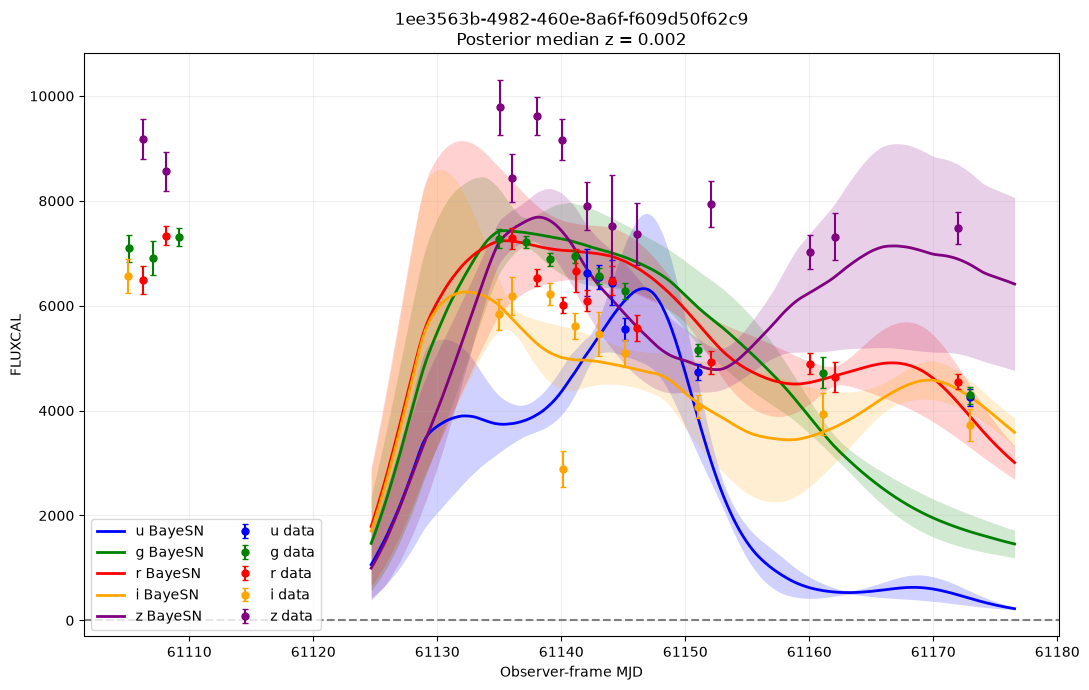

In [355]:
fig, ax = plt.subplots(figsize=(11, 7))

for band_index, band in enumerate(observed_bands):
    use = filters == band
    colour = colours[band]

    # Observed data
    ax.errorbar(
        t[use],
        flux[use],
        yerr=flux_err[use],
        fmt="o",
        ms=5,
        capsize=2,
        color=colour,
        label=f"{band} data",
        zorder=3,
    )

    # BayeSN prediction
    fitted_flux = model_mean[0, band_index]
    fitted_std = model_std[0, band_index]

    ax.plot(
        model_mjd[0],
        fitted_flux,
        color=colour,
        linewidth=2,
        label=f"{band} BayeSN",
        zorder=2,
    )

    ax.fill_between(
        model_mjd[0],
        fitted_flux - fitted_std,
        fitted_flux + fitted_std,
        color=colour,
        alpha=0.18,
        linewidth=0,
        zorder=1,
    )

z_median = np.median(z_samples)

ax.axhline(
    0,
    color="grey",
    linestyle="--",
)

ax.set(
    xlabel="Observer-frame MJD",
    ylabel="FLUXCAL",
    title=(
        f"{target_snid}\n"
        f"Posterior median z = {z_median:.3f}"
    ),
)

ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### New cut on nights and time span

In [328]:
matched = pd.read_csv(
    "alerce_match_partial.csv"
)

print(matched.columns.tolist())
display(matched.head())

['SNID', 'oid', 'sep_arcsec', 'p_SN', 'classifier_version']


,SNID,oid,sep_arcsec,p_SN,classifier_version
0,a3f7ac57-349f-44a8-bc11-dd101444ace1,3.138535e+17,0.004703,0.002284,202.0
1,14c2643a-48e6-4bae-a2e0-20b41cdbefaf,3.138535e+17,0.005537,0.001532,202.0
2,1ee3563b-4982-460e-8a6f-f609d50f62c9,3.138710e+17,0.007144,0.019884,202.0
3,23af3b06-9c88-44d8-a6c2-39a062326bbf,3.138535e+17,0.006170,0.003808,202.0
4,28ea9e0f-cd86-4b7e-becb-9970dd7a006c,3.138754e+17,0.019361,0.020532,202.0


In [331]:
results = []

for target_snid in matched["SNID"].astype(str).unique():

    # Find this SNID in HEAD
    snids = np.char.strip(
        head_data["SNID"].astype(str)
    )

    matches = np.flatnonzero(
        snids == target_snid
    )

    if len(matches) == 0:
        results.append({
            "SNID": target_snid,
            "survives": False,
            "reason": "not found in HEAD",
        })
        continue

    head_row = head_data[matches[0]]

    # Extract a fresh light curve
    lc = get_lightcurve(
        head_row,
        phot_data,
    )

    # Fix FITS byte ordering
    float_cols = lc.select_dtypes(
        include="float"
    ).columns

    lc[float_cols] = lc[
        float_cols
    ].astype("float32")
    lc["DETNUM"] = lc["DETNUM"].astype("int16")

    # Basic measurement cuts
    lc = lc[
        np.isfinite(lc["MJD"])
        & np.isfinite(lc["FLUXCAL"])
        & np.isfinite(lc["FLUXCALERR"])
        & (lc["FLUXCALERR"] > 0)
    ].copy()

    if len(lc) == 0:
        results.append({
            "SNID": target_snid,
            "survives": False,
            "reason": "no valid measurements",
        })
        continue

    # Remove extreme negative-flux outliers
    snr = lc["FLUXCAL"] / lc["FLUXCALERR"]

    lc = lc[
        snr > -5
    ].copy()

    if len(lc) == 0:
        results.append({
            "SNID": target_snid,
            "survives": False,
            "reason": "no data after point cuts",
        })
        continue

    # Sampling metrics after all point cuts
    n_observations = len(lc)
    n_nights = lc["MJD"].astype(int).nunique()
    time_span = lc["MJD"].max() - lc["MJD"].min()
    n_bands = lc["BAND"].nunique()

    # Object-level selection
    survives = (
        (n_nights >= 8)
        & (time_span >= 20)
    )

    reason = (
        "passes"
        if survives
        else "insufficient nights or time span"
    )

    results.append({
        "SNID": target_snid,
        "survives": survives,
        "reason": reason,
        "n_observations": n_observations,
        "n_nights": n_nights,
        "time_span": time_span,
        "n_bands": n_bands,
    })

In [332]:
cut_summary = pd.DataFrame(results)

print("Objects checked:", len(cut_summary))
print("Objects surviving:", cut_summary["survives"].sum())

display(
    cut_summary.sort_values(
        ["survives", "n_nights"],
        ascending=[False, False],
    )
)

Objects checked: 2277
Objects surviving: 681


,SNID,survives,reason,n_observations,n_nights,time_span,n_bands
0,a3f7ac57-349f-44a8-bc11-dd101444ace1,True,passes,147.0,66.0,180.679688,6.0
1,14c2643a-48e6-4bae-a2e0-20b41cdbefaf,True,passes,156.0,64.0,180.675781,6.0
3,23af3b06-9c88-44d8-a6c2-39a062326bbf,True,passes,147.0,63.0,180.699219,6.0
2,1ee3563b-4982-460e-8a6f-f609d50f62c9,True,passes,140.0,61.0,176.652344,6.0
4,28ea9e0f-cd86-4b7e-becb-9970dd7a006c,True,passes,139.0,59.0,175.652344,6.0
...,...,...,...,...,...,...,...
2250,424f9ec4-2ebb-4677-97d1-295930e0a22e,False,no data after point cuts,NaN,NaN,NaN,NaN
2251,23e60de3-5a34-443b-89c3-5f22fe7b95dc,False,no data after point cuts,NaN,NaN,NaN,NaN
2258,5c1843b3-c36c-4e33-b904-0330356760a3,False,no data after point cuts,NaN,NaN,NaN,NaN
2263,8a5174f0-c4b9-440e-97ed-7e63ed673d1e,False,no data after point cuts,NaN,NaN,NaN,NaN


In [333]:
surviving_objects = cut_summary[
    cut_summary["survives"]
].copy()

display(surviving_objects)

,SNID,survives,reason,n_observations,n_nights,time_span,n_bands
0,a3f7ac57-349f-44a8-bc11-dd101444ace1,True,passes,147.0,66.0,180.679688,6.0
1,14c2643a-48e6-4bae-a2e0-20b41cdbefaf,True,passes,156.0,64.0,180.675781,6.0
2,1ee3563b-4982-460e-8a6f-f609d50f62c9,True,passes,140.0,61.0,176.652344,6.0
3,23af3b06-9c88-44d8-a6c2-39a062326bbf,True,passes,147.0,63.0,180.699219,6.0
4,28ea9e0f-cd86-4b7e-becb-9970dd7a006c,True,passes,139.0,59.0,175.652344,6.0
...,...,...,...,...,...,...,...
1153,52252300-a09e-4a4c-adef-38632581b562,True,passes,10.0,8.0,131.695312,2.0
1154,00429afb-c43d-4215-b106-dd87b673c8b8,True,passes,8.0,8.0,131.656250,1.0
1156,94799a88-ea9a-4d00-9ab7-173c9050af5b,True,passes,9.0,8.0,114.785156,2.0
1158,476a6c12-99d4-4993-aa88-1663d71bb814,True,passes,8.0,8.0,127.339844,2.0


In [335]:
surviving_objects.to_csv(
    "alerce_match_surviving.csv",
    index=False,
)

In [363]:
snid = "38733078-e3b2-4817-9a86-64cae48a35fb"
print(head_data["RA"])

[282.909373 252.565374 307.694958 ... 282.266842 305.102062 341.45424 ]


### Cut to flat cont readings  // guassian best fit?

In [ ]:
import numpy as np
from scipy.optimize import curve_fit


def gaussian_model(t, baseline, amplitude, peak_mjd, width):
    return baseline + amplitude * np.exp(
        -0.5 * ((t - peak_mjd) / width) ** 2
    )


def gaussian_profile_metrics(lc, min_points=6):
    """
    Test whether a light curve is better described by a broad Gaussian
    transient than by a constant flux.

    Returns lenient profile-selection metrics.
    """

    use = (
        np.isfinite(lc["MJD"])
        & np.isfinite(lc["FLUXCAL"])
        & np.isfinite(lc["FLUXCALERR"])
        & (lc["FLUXCALERR"] > 0)
    )

    clean = lc.loc[use].copy()

    if len(clean) < min_points:
        return {
            "gaussian_fit_ok": False,
            "has_profile": False,
            "reason": "too few points",
        }

    t = clean["MJD"].to_numpy(dtype=float)
    flux = clean["FLUXCAL"].to_numpy(dtype=float)
    flux_err = clean["FLUXCALERR"].to_numpy(dtype=float)

    # Sort by time
    order = np.argsort(t)
    t = t[order]
    flux = flux[order]
    flux_err = flux_err[order]

    time_span = np.ptp(t)

    if time_span == 0:
        return {
            "gaussian_fit_ok": False,
            "has_profile": False,
            "reason": "zero time span",
        }

    # Best-fitting constant model: uncertainty-weighted mean
    weights = 1.0 / flux_err**2
    flat_flux = np.average(flux, weights=weights)

    chi2_flat = np.sum(
        ((flux - flat_flux) / flux_err) ** 2
    )

    # Starting estimates for Gaussian fit
    baseline_guess = np.percentile(flux, 20)
    peak_index = np.argmax(flux)

    amplitude_guess = max(
        flux[peak_index] - baseline_guess,
        np.median(flux_err),
    )

    peak_guess = t[peak_index]
    width_guess = max(time_span / 6, 2.0)

    try:
        parameters, covariance = curve_fit(
            gaussian_model,
            t,
            flux,
            sigma=flux_err,
            absolute_sigma=True,
            p0=[
                baseline_guess,
                amplitude_guess,
                peak_guess,
                width_guess,
            ],
            bounds=(
                [
                    -np.inf,       # baseline
                    0.0,           # positive amplitude
                    t.min(),       # peak inside observations
                    1.0,           # minimum width in days
                ],
                [
                    np.inf,
                    np.inf,
                    t.max(),
                    max(time_span * 2, 2.0),
                ],
            ),
            maxfev=20_000,
        )

        baseline, amplitude, peak_mjd, width = parameters

        model_flux = gaussian_model(t, *parameters)

        chi2_gaussian = np.sum(
            ((flux - model_flux) / flux_err) ** 2
        )

        delta_chi2 = chi2_flat - chi2_gaussian

        amplitude_error = np.sqrt(covariance[1, 1])

        if np.isfinite(amplitude_error) and amplitude_error > 0:
            amplitude_snr = amplitude / amplitude_error
        else:
            amplitude_snr = np.nan

        # Lenient cut: Gaussian merely needs to be noticeably better
        has_profile = (
            (delta_chi2 > 6)
            and (amplitude_snr > 2)
            and (width < time_span * 1.5)
        )

        return {
            "gaussian_fit_ok": True,
            "has_profile": has_profile,
            "chi2_flat": chi2_flat,
            "chi2_gaussian": chi2_gaussian,
            "delta_chi2": delta_chi2,
            "baseline": baseline,
            "amplitude": amplitude,
            "amplitude_snr": amplitude_snr,
            "peak_mjd": peak_mjd,
            "gaussian_width": width,
            "reason": (
                "Gaussian improvement"
                if has_profile
                else "mostly flat or weak profile"
            ),
        }

    except (RuntimeError, ValueError):
        return {
            "gaussian_fit_ok": False,
            "has_profile": False,
            "reason": "Gaussian fit failed",
        }